# 📈 Yield Prediction Model Training

This notebook was programmatically generated and aligned with the backend model specifications.

## 1. Imports and Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from xgboost import XGBRegressor
print('Libraries loaded!')


Libraries loaded!


## 2. Load Dataset


In [2]:
df_prod = pd.read_csv('../datasets/crop_production.csv')
df_prod = df_prod.dropna(subset=['Production']).copy()
print(f'Shape: {df_prod.shape}')


Shape: (242361, 7)


## 3. Preprocessing, Filtering, and Weather/NPK Augmentation


In [3]:
df_prod_tg = df_prod[df_prod['State_Name'].str.contains('Telangana|Andhra Pradesh', case=False, na=False)].copy()
if len(df_prod_tg) < 1000:
    df_prod_tg = df_prod.head(10000).copy()

df_crop_avg = pd.read_csv('../datasets/Crop_recommendation.csv')
crop_averages = df_crop_avg.groupby('label').mean().reset_index()

crop_name_mapping = {
    'paddy': 'rice', 'rice': 'rice', 'maize': 'maize', 'cotton(lint)': 'cotton', 
    'cotton': 'cotton', 'groundnut': 'groundnut', 'soyabean': 'soybean',
    'sugarcane': 'sugarcane', 'chickpea': 'chickpea', 'gram': 'chickpea'
}
df_prod_tg['crop_clean'] = df_prod_tg['Crop'].str.strip().str.lower().map(crop_name_mapping).fillna('rice')

df_merged = df_prod_tg.merge(crop_averages, left_on='crop_clean', right_on='label', how='left')

df_merged['N'] = df_merged['N'].fillna(crop_averages['N'].mean())
df_merged['P'] = df_merged['P'].fillna(crop_averages['P'].mean())
df_merged['K'] = df_merged['K'].fillna(crop_averages['K'].mean())
df_merged['temperature'] = df_merged['temperature'].fillna(crop_averages['temperature'].mean())
df_merged['humidity'] = df_merged['humidity'].fillna(crop_averages['humidity'].mean())
df_merged['rainfall'] = df_merged['rainfall'].fillna(crop_averages['rainfall'].mean())

soil_map_dataset = {'rice': 3, 'cotton': 1, 'maize': 0, 'groundnut': 4}
df_merged['soil_encoded'] = df_merged['crop_clean'].map(soil_map_dataset).fillna(5).astype(int)

crop_map_yield = {
    'rice': 0, 'maize': 1, 'cotton': 2, 'chickpea': 3, 'pigeonpeas': 4, 'groundnut': 5, 'soybean': 6, 'sugarcane': 7
}
df_merged['crop_encoded'] = df_merged['crop_clean'].map(crop_map_yield).fillna(0).astype(int)
df_merged['yield_quintals'] = df_merged['Production'] * 10.0

X = df_merged[['crop_encoded', 'Area', 'soil_encoded', 'N', 'P', 'K', 'temperature', 'humidity', 'rainfall']].values
y = df_merged['yield_quintals'].values
print(f'Features shape: {X.shape}')


Features shape: (15152, 9)


## 4. Model Training


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=30, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
print('XGBoost yield model trained!')


XGBoost yield model trained!


## 5. Evaluation Metrics & Scatter Plot


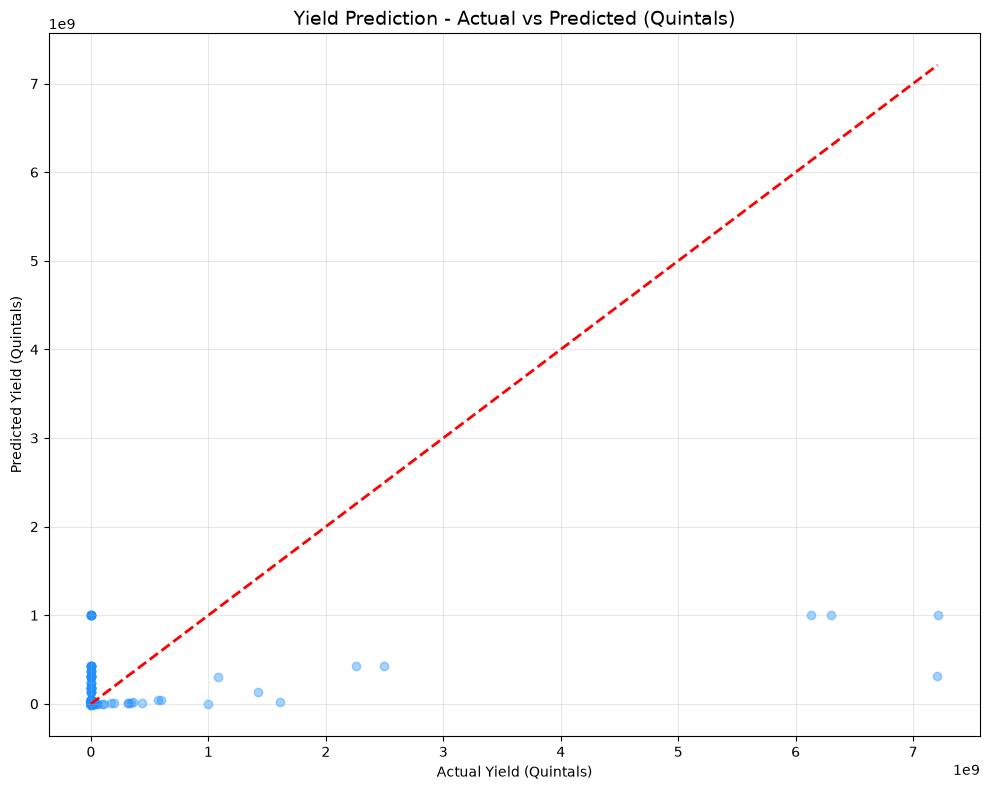

YIELD PREDICTION EVALUATION METRICS
R² (Coefficient of Determination) score: 0.1663
Mean Absolute Error (MAE):              20574567.54 quintals
Root Mean Squared Error (RMSE):          234561699.97 quintals


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = xgb_model.predict(X_test)

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Yield Prediction - Actual vs Predicted (Quintals)', fontsize=14)
plt.xlabel('Actual Yield (Quintals)')
plt.ylabel('Predicted Yield (Quintals)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yield_prediction_scatter.png', dpi=150)
plt.show()

print("="*60)
print("YIELD PREDICTION EVALUATION METRICS")
print("="*60)
print(f"R² (Coefficient of Determination) score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error (MAE):              {mean_absolute_error(y_test, y_pred):.2f} quintals")
print(f"Root Mean Squared Error (RMSE):          {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} quintals")


## 6. Save Model File


In [6]:
os.makedirs('../../ml_models', exist_ok=True)
with open('../../ml_models/yield_prediction.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print('Successfully saved yield model!')


Successfully saved yield model!
